In [1]:
import pandas as pd

In [62]:
df = pd.read_csv("../Data/ai_job_dataset.csv")
# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

# 국가, 직군, 연차

Dataset Shape: (15000, 19)

Memory Usage: 2.17 MB

First few rows:


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.90,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.20,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.40,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.60,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.60,Advanced Robotics


In [63]:
# 숫자형 변환
df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')

In [64]:
# 사분위수 계산
q1 = df['salary_usd'].quantile(0.25)
q2 = df['salary_usd'].quantile(0.50)
q3 = df['salary_usd'].quantile(0.75)

# 연봉 등급 라벨링 (4단계)
def label_salary_4group(salary):
    if salary <= q1:
        return 'very_low'
    elif salary <= q2:
        return 'low'
    elif salary <= q3:
        return 'mid'
    else:
        return 'high'

df['salary_label'] = df['salary_usd'].apply(label_salary_4group)

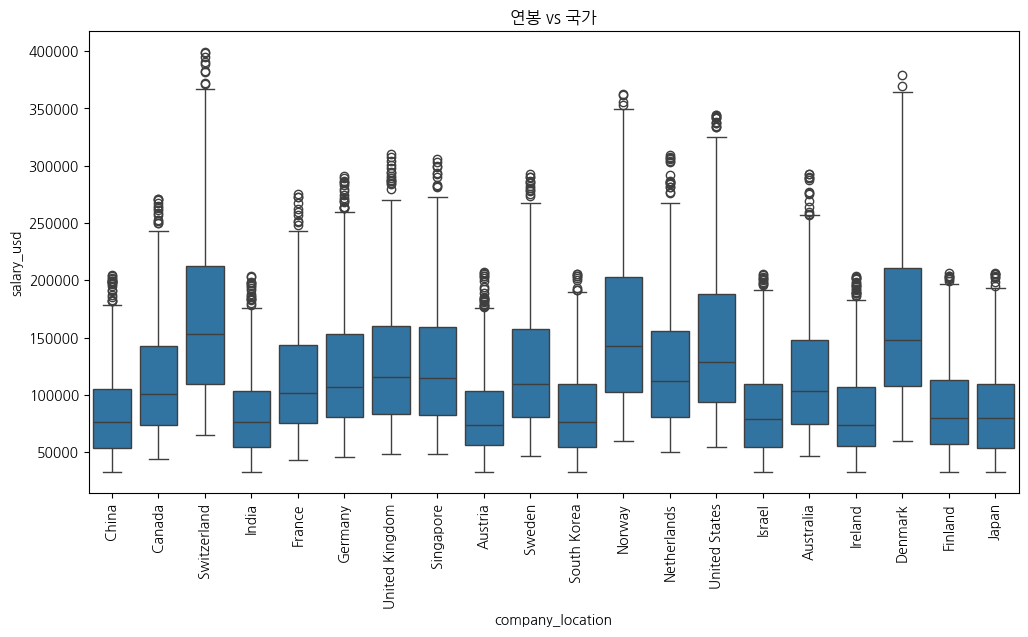

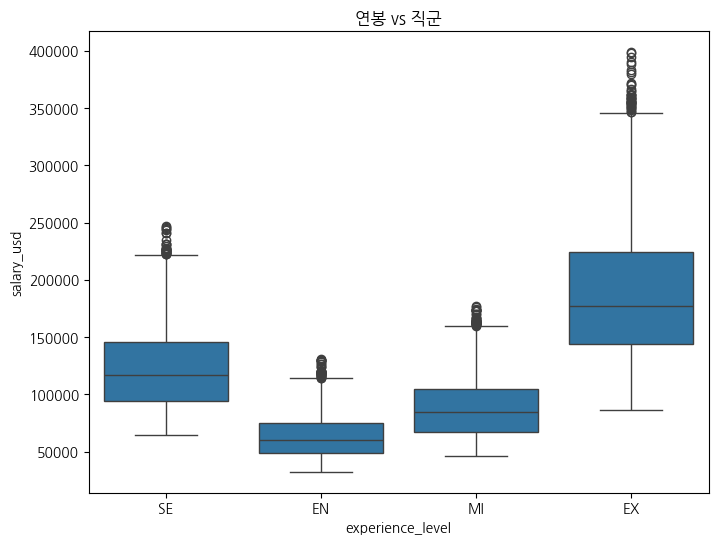

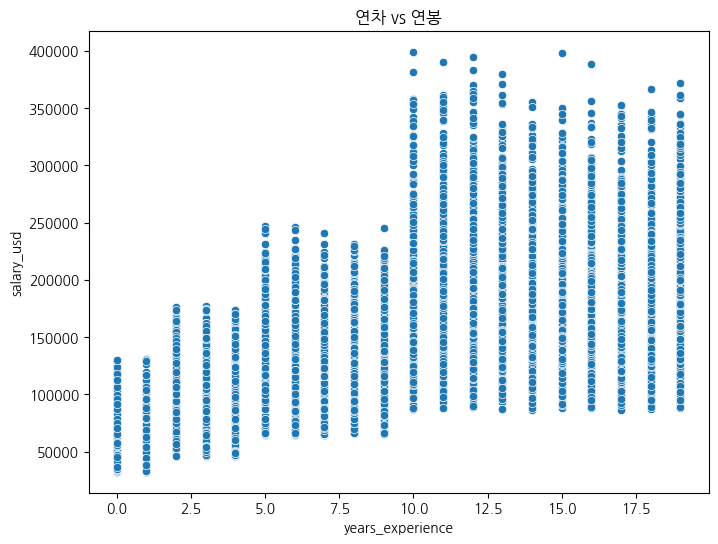

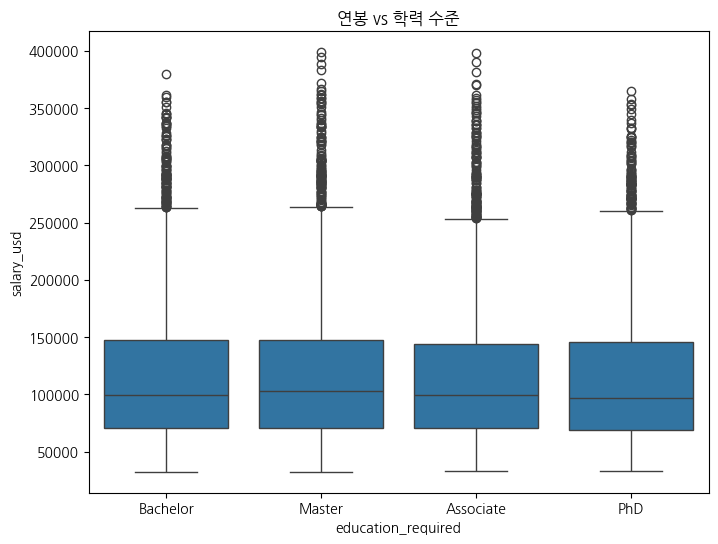

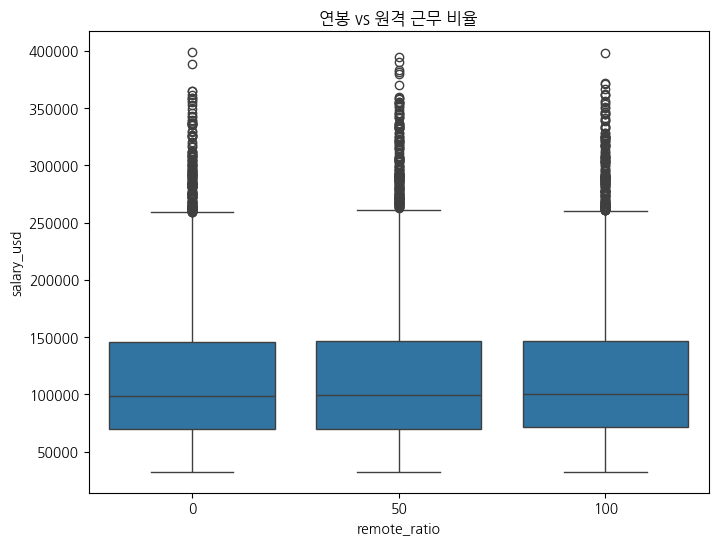

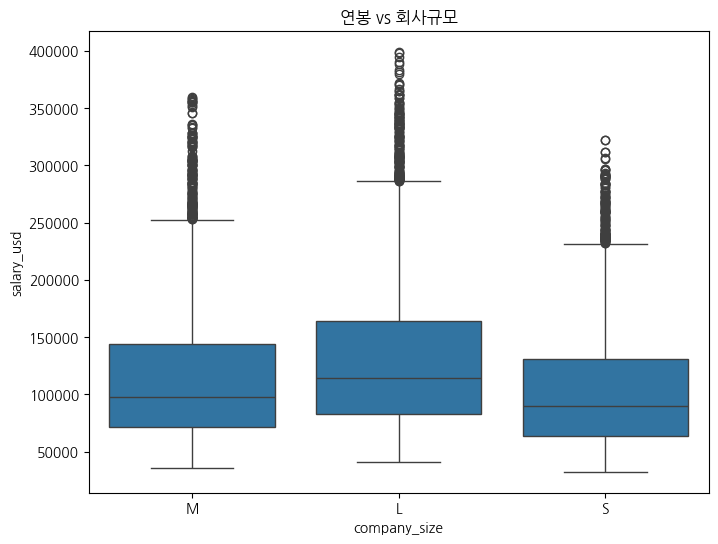

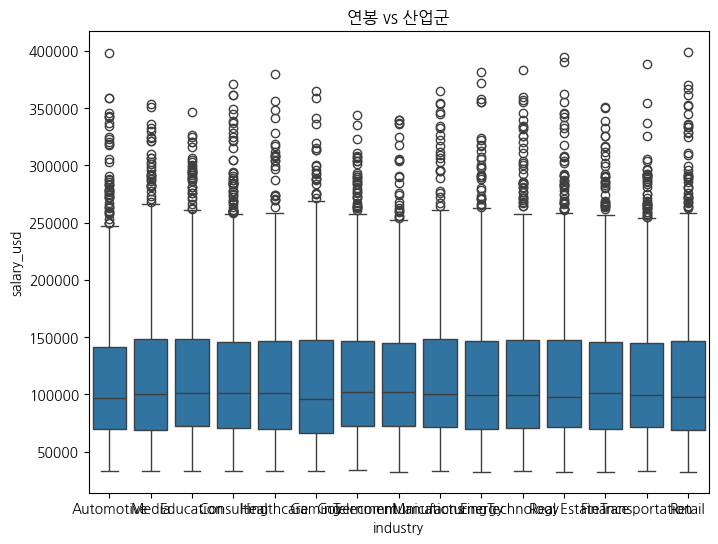

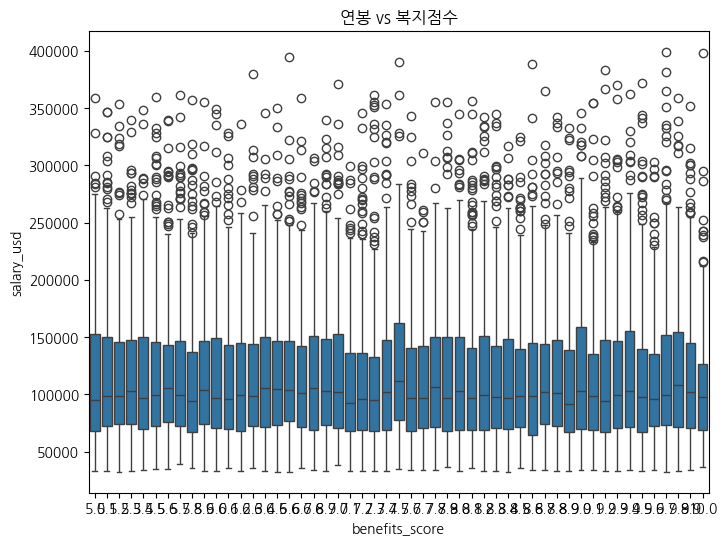

In [65]:
# 

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import koreanize_matplotlib

# 국가별 연봉 분포
plt.figure(figsize=(12, 6))
sns.boxplot(x='company_location', y='salary_usd', data=df)
plt.xticks(rotation=90)
plt.title("연봉 vs 국가")
plt.show()

# 경력레벨별 연봉 분포
plt.figure(figsize=(8, 6))
sns.boxplot(x='experience_level', y='salary_usd', data=df)
plt.title("연봉 vs 직군")
plt.show()

# 연차 vs 연봉 산점도
plt.figure(figsize=(8, 6))
sns.scatterplot(x='years_experience', y='salary_usd', data=df)
plt.title("연차 vs 연봉")
plt.show()


# 학력수준
plt.figure(figsize=(8, 6))
sns.boxplot(x='education_required', y='salary_usd', data=df)
plt.title("연봉 vs 학력 수준")
plt.show()


# 원격 비율
plt.figure(figsize=(8, 6))
sns.boxplot(x='remote_ratio', y='salary_usd', data=df)
plt.title("연봉 vs 원격 근무 비율")
plt.show()

# 회사규모
plt.figure(figsize=(8, 6))
sns.boxplot(x='company_size', y='salary_usd', data=df)
plt.title("연봉 vs 회사규모")
plt.show()


# 산업군
plt.figure(figsize=(8, 6))
sns.boxplot(x='industry', y='salary_usd', data=df)
plt.title("연봉 vs 산업군")
plt.show()



# 복지점수
plt.figure(figsize=(8, 6))
sns.boxplot(x='benefits_score', y='salary_usd', data=df)
plt.title("연봉 vs 복지점수")
plt.show()

In [ ]:
# 2. 필요한 feature 추출

df_subset = df[['company_location', 'years_experience', 'salary_label', 'benefits_score', 'industry', 'compan']].dropna()


In [67]:
# 3. 원핫인코딩 + 스케일링

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 컬럼 정의
cat_cols = ['company_location', 'experience_level']
num_cols = ['years_experience']

# 전처리 파이프라인
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
X_processed = preprocessor.fit_transform(df_subset.drop('salary_label', axis=1))

In [68]:
# 4. PCA로 2차원 축소

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed.toarray())

In [69]:
# 5. k=4으로 Kmeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_subset['cluster'] = clusters

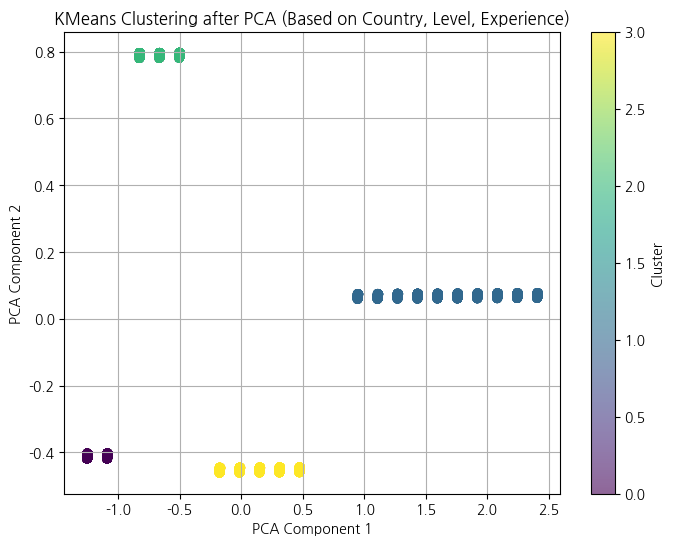

In [70]:
# 6. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering after PCA (Based on Country, Level, Experience)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [71]:
pd.crosstab(df_subset['salary_label'], df_subset['cluster'])

cluster,0,1,2,3
salary_label,,,,
high,0,2747,98,905
low,1027,113,1515,1095
mid,161,900,1033,1656
very_low,2530,0,1135,85


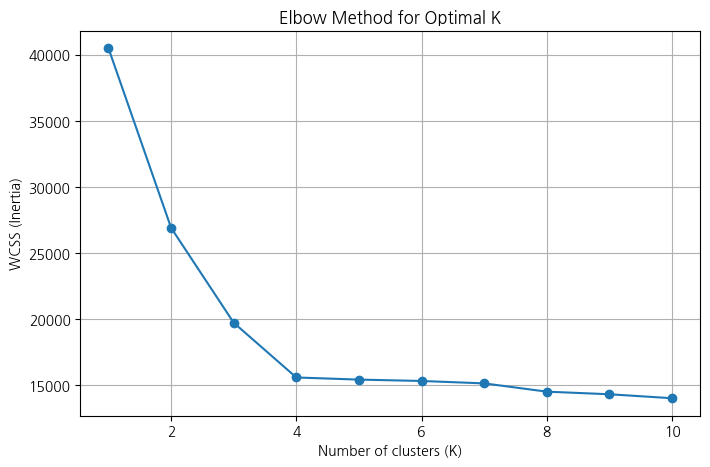

In [72]:
# 최적의 K값 찾기

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-cluster sum of squares

# 1~10까지 K값에 대해 반복
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [81]:
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# ========================
# 1. 클러스터링: 군집 생성
# ========================
# 클러스터 만들 때 사용할 feature만 선택
clustering_features = ['years_experience']  # 예시: 연차만 사용

# 전처리
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[['years_experience']])

# KMeans 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

# ============================
# 2. 클러스터 예측용 모델 학습
# ============================
# 💡 클러스터 생성에 사용하지 않았던 feature만 사용
predict_features = ['company_location', 'experience_level', 'education_required', 'industry']

df_subset = df[predict_features + ['cluster']].dropna()

X = df_subset[predict_features]
y = df_subset['cluster']

# 학습/검증 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 전처리 파이프라인
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 학습
pipeline.fit(X_train, y_train)

# 예측 및 평가
y_pred = pipeline.predict(X_test)

print("✅ 정확도 (Accuracy):", pipeline.score(X_test, y_test))
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

✅ 정확도 (Accuracy): 0.6916666666666667

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       991
           1       0.54      0.54      0.54       670
           2       0.70      0.81      0.75       528
           3       0.61      0.59      0.60       811

    accuracy                           0.69      3000
   macro avg       0.68      0.69      0.68      3000
weighted avg       0.69      0.69      0.69      3000

🧩 Confusion Matrix:
[[810   0   0 181]
 [  0 359 181 130]
 [  0 102 426   0]
 [131 200   0 480]]


In [73]:
df_subset.groupby('cluster')[['years_experience']].mean()

,years_experience
cluster,
0,0.49
1,14.48
2,3.01
3,6.98


In [74]:
df_subset['cluster'] = clusters  # 클러스터 번호가 저장된 변수
df_subset = df_subset.join(df[['salary_usd']], how='left')
df_subset.groupby('cluster')['salary_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,3718.00,63133.38,18558.10,32519.00,48516.00,60373.50,74866.50,131006.00
1,3760.00,187723.65,59316.74,86536.00,143966.00,177512.00,224549.50,399095.00
2,3781.00,87955.47,25543.11,45900.00,67621.00,84641.00,104483.00,177470.00
3,3741.00,122187.66,35261.62,64824.00,94173.00,116907.00,145315.00,247271.00


In [75]:
df_subset.groupby('cluster')['company_location'].value_counts(normalize=True)

cluster  company_location
0        Australia          0.05
         China              0.05
         South Korea        0.05
         Ireland            0.05
         Switzerland        0.05
                            ... 
3        Norway             0.05
         Ireland            0.05
         United States      0.05
         Netherlands        0.05
         Australia          0.05
Name: proportion, Length: 80, dtype: float64

In [76]:
df_subset.groupby('cluster')['experience_level'].value_counts(normalize=True)

cluster  experience_level
0        EN                 1.00
1        EX                 1.00
2        MI                 1.00
3        SE                 1.00
Name: proportion, dtype: float64

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

In [77]:
# feature와 label 분리
X = df_subset[['company_location', 'experience_level', 'years_experience']]
y = df_subset['cluster']  # KMeans로 생성한 클러스터 번호

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. 컬럼 구분
cat_cols = ['company_location', 'experience_level']
num_cols = ['years_experience']

# 2. 전처리 파이프라인 구성
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 3. 전체 파이프라인 구성
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4. 학습
pipeline.fit(X_train, y_train)

# 5. 예측
y_pred = pipeline.predict(X_test)

# 6. 평가
print("✅ 정확도 (Accuracy):", pipeline.score(X_test, y_test))
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

✅ 정확도 (Accuracy): 1.0

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       744
           1       1.00      1.00      1.00       752
           2       1.00      1.00      1.00       756
           3       1.00      1.00      1.00       748

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

🧩 Confusion Matrix:
[[744   0   0   0]
 [  0 752   0   0]
 [  0   0 756   0]
 [  0   0   0 748]]


In [55]:
y_pred = pipeline.predict(X_test)

print("✅ Classification Report:\n")
print(classification_report(y_test, y_pred))

print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

✅ Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       744
           1       1.00      1.00      1.00       752
           2       1.00      1.00      1.00       756
           3       1.00      1.00      1.00       748

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

🧩 Confusion Matrix:
[[744   0   0   0]
 [  0 752   0   0]
 [  0   0 756   0]
 [  0   0   0 748]]


In [ ]:
# 예측 입력
new_input = pd.DataFrame([{
    'company_location': 'US',
    'experience_level': 'SE',
    'years_experience': 6
}])

# 클러스터 예측
predicted_cluster = pipeline.predict(new_input)[0]

# 클러스터별 메시지
cluster_messages = {
    0: "💼 저연봉/초급자 클러스터",
    1: "🚀 고연봉/시니어 전문가 클러스터",
    2: "📈 중간 연봉/주니어~중급 클러스터",
    3: "🧠 중상위 경력자 클러스터"
}

# 클러스터별 연봉 요약 계산 (df_subset은 cluster + salary_usd 포함된 데이터프레임)
salary_stats = df_subset.groupby('cluster')['salary_usd'].agg(['min', 'mean', 'max']).round(0)

# 예측된 클러스터에 대한 메시지와 연봉 범위 출력
msg = cluster_messages.get(predicted_cluster, "알 수 없는 클러스터")
stats = salary_stats.loc[predicted_cluster]

print(f"당신은 {msg}에 속합니다.")
print(f"💰 이 클러스터의 평균 연봉은 ${int(stats['mean']):,}이며,")
print(f"    최소 ${int(stats['min']):,} ~ 최대 ${int(stats['max']):,} 범위에 분포합니다.")

당신은 🧠 중상위 경력자 클러스터에 속합니다.
💰 이 클러스터의 평균 연봉은 $122,188이며,
    최소 $64,824 ~ 최대 $247,271 범위에 분포합니다.


In [57]:
# 클러스터별 연봉, 연차 등 평균값
cluster_summary = df_subset.groupby('cluster').agg({
    'salary_usd': ['mean', 'min', 'max'],
    'years_experience': 'mean',
    'company_location': lambda x: x.mode()[0],
    'experience_level': lambda x: x.mode()[0]
})

In [26]:
cluster_info = {
    0: "📉 저연차/저연봉군입니다. 평균 연봉은 약 $63K이며, 평균 경력은 0.5년입니다.",
    1: "💼 고연차/고연봉군입니다. 평균 연봉은 $187K이며, 시니어 이상 전문가 비율이 높습니다.",
    2: "📈 주니어~중급군입니다. 평균 연봉은 약 $88K이며, 3년차 개발자가 많습니다.",
    3: "🧠 중상위 클러스터입니다. 평균 연봉은 $122K이고, 경력 7년 이상 중급 이상입니다."
}

print(f"당신은 cluster {predicted_cluster}번에 속합니다.")
print(cluster_info[predicted_cluster])

당신은 cluster 3번에 속합니다.
🧠 중상위 클러스터입니다. 평균 연봉은 $122K이고, 경력 7년 이상 중급 이상입니다.


In [27]:
!pip install flaml